In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite',
    google_api_key=os.getenv('GEMINI_API_KEY')
)

In [3]:
class Joke(TypedDict):

    topic : str
    joke : str
    explaination : str

In [4]:
def generate_joke(state: Joke):

    topic=state['topic']

    prompt=f'generate a joke on the given topic {topic}'

    joke=llm.invoke(prompt)

    return{'joke':joke}

In [5]:
def explain_joke(state:Joke):

    joke=state['joke']
    prompt=f'explain the following joke in easy language {joke}'

    exp=llm.invoke(prompt)
    return{'explaination':exp}

In [6]:
graph = StateGraph(Joke)

graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer=InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


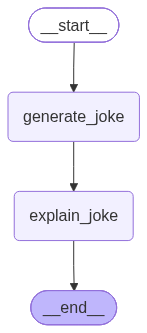

In [8]:
workflow

In [12]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'college placements'}, config=config1)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'topic': 'college placements',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'Here are a few jokes about college placements, depending on your vibe:\n\n**The Optimist vs. Pessimist**\nA student asks his professor, "Sir, what’s the secret to getting placed at a top company?"\nThe professor sighs, "It’s a three-step process: \n1. Build a stellar resume. \n2. Master your data structures and algorithms. \n3. Have a father who sits on the company\'s Board of Directors."\n\n**The Reality Check**\nDuring a placement interview, the HR manager asks, "Where do you see yourself in five years?"\nThe student replies, "To be honest, I just want to see myself in a cubicle with a paycheck that clears before my electricity bill is due."\n\n**The Technical Difficulty**\nAn engineering student walks out of his final placement interview. His friend asks, "How did it go?"\nThe student says, "It was great! They asked me what a \'distributed system\' was, and I told them the truth—that’s exactly how 

In [13]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'college placements', 'joke': AIMessage(content=[{'type': 'text', 'text': 'Here are a few jokes about college placements, depending on your vibe:\n\n**The Optimist vs. Pessimist**\nA student asks his professor, "Sir, what’s the secret to getting placed at a top company?"\nThe professor sighs, "It’s a three-step process: \n1. Build a stellar resume. \n2. Master your data structures and algorithms. \n3. Have a father who sits on the company\'s Board of Directors."\n\n**The Reality Check**\nDuring a placement interview, the HR manager asks, "Where do you see yourself in five years?"\nThe student replies, "To be honest, I just want to see myself in a cubicle with a paycheck that clears before my electricity bill is due."\n\n**The Technical Difficulty**\nAn engineering student walks out of his final placement interview. His friend asks, "How did it go?"\nThe student says, "It was great! They asked me what a \'distributed system\' was, and I told them the truth

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'college placements', 'joke': AIMessage(content=[{'type': 'text', 'text': 'Here are a few jokes about college placements, depending on your vibe:\n\n**The Optimist vs. Pessimist**\nA student asks his professor, "Sir, what’s the secret to getting placed at a top company?"\nThe professor sighs, "It’s a three-step process: \n1. Build a stellar resume. \n2. Master your data structures and algorithms. \n3. Have a father who sits on the company\'s Board of Directors."\n\n**The Reality Check**\nDuring a placement interview, the HR manager asks, "Where do you see yourself in five years?"\nThe student replies, "To be honest, I just want to see myself in a cubicle with a paycheck that clears before my electricity bill is due."\n\n**The Technical Difficulty**\nAn engineering student walks out of his final placement interview. His friend asks, "How did it go?"\nThe student says, "It was great! They asked me what a \'distributed system\' was, and I told them the trut

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': AIMessage(content=[{'type': 'text', 'text': 'Why did the pasta go to the doctor?\n\nBecause he was feeling a little **cannelloni**!', 'extras': {'signature': 'EnEKbwFpFH0Tf9nB4mHssKP/xNI9ClvWeWvUnomTX+ewEGARO54YyplQ1BUmVMO/2UrgBQdjQwKohfT8zFUB0fnIRpXP8BvAF1D+o6E063x1LvcvbgI9oOnl7MSWf6aSNuVBo2AIyGSt4zRIo53LHdEHvw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c2c3-63da-7d80-b369-9bc06748e7da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 22, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}}),
 'explaination': AIMessage(content=[{'type': 'text', 'text': 'This joke is a play on words:\n\n1.  **The pun:** "Cannelloni" is a type of pasta.\n2.  **The sound:** It sounds very similar to the phrase "can only" (as in, "feeling a little **can-only**"). \n3.  **The meaning:** 

In [16]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content=[{'type': 'text', 'text': 'Why did the pasta go to the doctor?\n\nBecause he was feeling a little **cannelloni**!', 'extras': {'signature': 'EnEKbwFpFH0Tf9nB4mHssKP/xNI9ClvWeWvUnomTX+ewEGARO54YyplQ1BUmVMO/2UrgBQdjQwKohfT8zFUB0fnIRpXP8BvAF1D+o6E063x1LvcvbgI9oOnl7MSWf6aSNuVBo2AIyGSt4zRIo53LHdEHvw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c2c3-63da-7d80-b369-9bc06748e7da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 22, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}}), 'explaination': AIMessage(content=[{'type': 'text', 'text': 'This joke is a play on words:\n\n1.  **The pun:** "Cannelloni" is a type of pasta.\n2.  **The sound:** It sounds very similar to the phrase "can only" (as in, "feeling a little **can-only**"). \n3